Title: SEM_application.ipynb

Purpose: 

Author: Onno Nennecke on 19.03.2025 Modified: 03.05.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Define variables (all in the config file)


```python
Wind:
- alpha_on = 1/7    # Roughness parameter onshore  
- alpha_off = 0.11  # Roughness parameter offshore  
- ref_height = 10   # Height of wind data  
- v_cutin = 3.5     # Minimum wind speed to start producing power  
- v_cutout = 25     # Maximum wind speed to produce power  
- v_rated = 13      # Wind speed at which the turbine produces maximum power  
- time_oper = 24    # operational time of hub [h/day]  
- Hub Height:
    - # hub_height_on = 80    # Approximation: Onshore 80 m --> Bad Approximation --> Used own grid data instead  
    - # hub_height_off = 120  # Approximation: Offshore 120 m --> Bad Approximation --> Used own grid data instead  

Solar:

- cT_c1 = 4.3       # constant [dC]  
- cT_c2 = 0.943     # constant [-]  
- cT_c3 = 0.028     # constant [dC m2 W-1]  
- cT_c4 = -1.528    # constant [dC s m-1]  
- gamma = -0.005    # constant [--]  
- temp_ref = 25     # reference temperature [dC]  
- gstc = 1000       # standard test conditions [W m-2]  
- shift_doy = 186   # if HadGEM : 180  
```

### Load datasets

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

In [3]:
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [4]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

In [5]:
# Load bias data
# biases = pd.read_csv('/climca/people/onennecke/model_output/var_means/biases.csv')
biases = pd.read_csv('/climca/people/onennecke/model_output/var_means_masked/biases.csv')

biases

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,4.211840,4.691658,-2.133586,53.578545,59.9273,-6.301769,3.645760,4.073766,-1.458157,5.604193,6.583297,-2.100756
1,BCC-CSM2-MR,4.831176,4.691658,-1.514250,47.889800,59.9273,-11.990513,4.574496,4.073766,-0.529422,6.677243,6.583297,-1.027706
2,CESM2,5.042759,4.691658,-1.302667,60.249096,59.9273,0.368782,6.104048,4.073766,1.000131,8.581801,6.583297,0.876853
3,EC-Earth3,4.912206,4.691658,-1.433220,61.514250,59.9273,1.633938,4.012864,4.073766,-1.091054,6.694421,6.583297,-1.010528
4,ERA5,6.345426,4.691658,0.000000,59.880314,59.9273,0.000000,5.103918,4.073766,0.000000,7.704949,6.583297,0.000000
5,GFDL-ESM4,5.159821,4.691658,-1.185605,54.001675,59.9273,-5.878639,3.609791,4.073766,-1.494126,5.608334,6.583297,-2.096615
6,KACE-1-0-G,4.991951,4.691658,-1.353475,57.075626,59.9273,-2.804688,3.792399,4.073766,-1.311519,5.882808,6.583297,-1.822141
7,MPI-ESM1-2-HR,4.628232,4.691658,-1.717194,51.053043,59.9273,-8.827270,3.627550,4.073766,-1.476367,5.897475,6.583297,-1.807474
8,MRI-ESM2-0,4.202353,4.691658,-2.143073,63.341995,59.9273,3.461681,5.751032,4.073766,0.647114,7.849053,6.583297,0.144104
9,TaiESM1,3.802679,4.691658,-2.542747,58.571175,59.9273,-1.309139,6.173880,4.073766,1.069962,9.466802,6.583297,1.761853


### Define used models

In [6]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
#            'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
# ESMs = ['MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'

# ESMs = ['EC-Earth3'] # 'EC-Earth3-Veg'

# ESMs = ['UKESM1-0-LL']
# ESMs = ['TaiEMS1', 'UKESM1-0LL']
scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'


In [ ]:
# Check which directories are (already) available and if they contain all the variables
# ESMs = ['EC-Earth3']
'''
for ESM in ESMs:
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    print(ESM,': ')
    if len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0])
        print(runs)
        
    else:
        print('No matching directory found')
        continue
    for run in runs:
        run_path = os.path.join(matching_dirs[0], run, 'day')
        print('run_path: ', run_path)
        # Check if all required folders (in `variables`) exist
        # missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        # if missing_folders:
        #     print(f"Missing folders in {run_path}: {missing_folders}")
        #     continue
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
'''

ACCESS-CM2 : 
['r4i1p1f1', 'r5i1p1f1', 'r1i1p1f1']
run_path:  /climca/data/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp370/r4i1p1f1/day
run_path:  /climca/data/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp370/r5i1p1f1/day
run_path:  /climca/data/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp370/r1i1p1f1/day
BCC-CSM2-MR : 
['r1i1p1f1']
run_path:  /climca/data/CMIP6/ScenarioMIP/BCC/BCC-CSM2-MR/ssp370/r1i1p1f1/day
CESM2 : 
['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
run_path:  /climca/data/CMIP6/ScenarioMIP/NCAR/CESM2/ssp370/r4i1p1f1/day
run_path:  /climca/data/CMIP6/ScenarioMIP/NCAR/CESM2/ssp370/r10i1p1f1/day
run_path:  /climca/data/CMIP6/ScenarioMIP/NCAR/CESM2/ssp370/r11i1p1f1/day
EC-Earth3 : 
['r149i1p1f1', 'r6i1p1f1', 'r4i1p1f1', 'r148i1p1f1', 'r105i1p1f1', 'r9i1p1f1', 'r134i1p1f1', 'r141i1p1f1', 'r146i1p1f1', 'r15i1p1f1', 'r112i1p1f1', 'r117i1p1f1', 'r125i1p1f1', 'r113i1p1f1', 'r106i1p1f1', 'r138i1p1f1', 'r5i1p1f1', 'r137i1p1f1', 'r11i1p1f1', 'r145i1p1f1', 'r114i1p1f1', 'r120i1p1f1', 'r12

In [7]:
# Only the loading part of the model for testing 
'''
# List to hold individual datasets (one for each variable)
ds_list = []

for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/ScenarioMIP/*/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        print('Run: ', run)
        run_path = os.path.join(matching_dirs[0], run, 'day/')
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        for variable in variables:
            print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/ScenarioMIP/*/{ESM}/{scenario}/{run}/day/{variable}/*/*/{variable}_day_{ESM}_{scenario}_{run}_*'
            print('Open: ', path)
            # Open with preprocessing (spatial filtering)
            nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
        #     # Filter to only winter months (October to March)
        #     # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

            # Filter to only winter months (October to March)
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        # if ds_list[2]['tas'].units == 'K':
        #     clim_ds['tas'] = clim_ds['tas'] - 273.15

        # if ds_list[3]['tasmax'].units == 'K':
        #     clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # # Regrid the combined dataset
        # combined_ds = grid_func.regrid(clim_ds)
        
        break
'''

'\n# List to hold individual datasets (one for each variable)\nds_list = []\n\nfor ESM in ESMs:\n    print(\'ESM: \', ESM)\n    path = f\'/climca/data/CMIP6/ScenarioMIP/*/{ESM}/{scenario}/\'\n    matching_dirs = glob.glob(path)\n    if len(matching_dirs) == 1:\n        runs = os.listdir(matching_dirs[0])\n    else:\n        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")\n        break\n    print(\'Runs: \', runs)\n    for run in runs:\n        print(\'Run: \', run)\n        run_path = os.path.join(matching_dirs[0], run, \'day/\')\n\n        # Check if all required folders (in `variables`) exist\n        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]\n\n        if missing_folders:\n            print(f"Missing folders in {run_path}: {missing_folders}")\n            continue\n        for variable in variables:\n            print(\'Variable: \', variable)\n            #path =f\'/climca/data/CMIP6/CMIP/NCAR/

In [7]:
# Takes about 390 min  ~6,5h
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
        #     # Filter to only winter months (October to March)
        #     # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
            
        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # Apply bias correction
        clim_ds['sfcWind'] = clim_ds['sfcWind'] - biases.loc[biases['ESM'] == ESM, 'bias_sfcWind'].values[0]
        clim_ds['rsds'] = clim_ds['rsds'] - biases.loc[biases['ESM'] == ESM, 'bias_rsds'].values[0]
        clim_ds['tas'] = clim_ds['tas'] - biases.loc[biases['ESM'] == ESM, 'bias_tas'].values[0]
        clim_ds['tasmax'] = clim_ds['tasmax'] - biases.loc[biases['ESM'] == ESM, 'bias_tasmax'].values[0]
            
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
        wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, config.height_ref)
        
        combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
        combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']
        
        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
        weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)
        
        combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
        combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']
        
        sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['sfcWind'])
        
        # combined_ds['solar_pot'] = sepot['solar_pot']        
        combined_ds['solar_pot'] = sepot
        
        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)
        
        # combined_ds['solar_prod'] = seprod['solar_prod']
        combined_ds['solar_prod'] = seprod

        
        # Calculate weighted sum

        weighted_temp_list = []
        for y in np.unique(combined_ds['tas']["time.year"].values):
            # print(y)
            ds_weigh_temp_0 = xr.Dataset()
            ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
            weighted_temp_list.append(ds_weigh_temp_0)
            
        ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
        
        # Calculate demand
        demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))
        
        timeseries_ds = demand_ds.copy()

        # timeseries_ds['sfcWind_ntmsk'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_ntmsk'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tas_ntmsk'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax_ntmsk'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        timeseries_ds['sfcWind'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        
        # timeseries_ds['sfcWind'] = (combined_ds['sfcWind'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tas']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])
        
        timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000
        
        timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected/full_year/{ESM}_{run}_timeseries.nc')
        ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ESM:  ACCESS-CM2
Runs:  ['r4i1p1f1', 'r5i1p1f1', 'r1i1p1f1']
Run:  r4i1p1f1 Number:  1 of  3
Run time:  3 m 28.8 s
Run:  r5i1p1f1 Number:  2 of  3
Run time:  3 m 26.8 s
Run:  r1i1p1f1 Number:  3 of  3
Run time:  3 m 32.7 s
ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 3.2 s
ESM:  CESM2
Runs:  ['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
Run:  r4i1p1f1 Number:  1 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  3 m 5.5 s
Run:  r10i1p1f1 Number:  2 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  3 m 6.3 s
Run:  r11i1p1f1 Number:  3 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  3 m 5.4 s
ESM:  EC-Earth3
Runs:  ['r149i1p1f1', 'r6i1p1f1', 'r4i1p1f1', 'r148i1p1f1', 'r105i1p1f1', 'r9i1p1f1', 'r134i1p1f1', 'r141i1p1f1', 'r146i1p1f1', 'r15i1p1f1', 'r112i1p1f1', 'r117i1p1f1', 'r125i1p1f1', 'r113i1p1f1', 'r106i1p1f1', 'r138i1p1f1', 'r5i1p1f1', 'r137i1p1f1', 'r11i1p1f1', 'r145i1p1f1', 'r114i1p1f1', 'r120i1p1f1', 'r128i1p1f1', 'r135i1p1f1', 'r110i1p1f1', 'r129i1p1f1', 'r132i1p1f1', 'r101i1p1f1', 'r124i1p1f1', 'r127i1p1f1', 'r116i1p1f1', 'r131i1p1f1', 'r121i1p1f1', 'r142i1p1f1', 'r102i1p1f1', 'r133i1p1f1', 'r111i1p1f1', 'r140i1p1f1', 'r136i1p1f1', 'r108i1p1f1', 'r130i1p1f1', 'r150i1p1f1', 'r104i1p1f1', 'r118i1p1f1', 'r109i1p1f1', 'r143i1p1f1', 'r147i1p1f1', 'r126i1p1f1', 'r13i1p1f1', 'r119i1p1f1', 'r1i1p1f1', 'r123i1p1f1', 'r122i1p1f1', 'r115i1p1f1', 'r103i1p1f1', 'r144i1p1f1', 'r139i1p1f1', 'r107i1p1f1']
Run:  r149i1p1f1 Number:  1 of  58
Run time:  4 m 10.4 s
Run:  r6i1p1f1 Number:  2 of  58
Missing data in /climca/data/CMIP6/ScenarioMIP/EC-Earth-Consortium

In [8]:
ts_output

<xarray.Dataset> Size: 375kB
Dimensions:        (time: 3600)
Coordinates:
  * time           (time) object 29kB 2015-01-01 12:00:00 ... 2024-12-30 12:0...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U7 28B 'week'
    run            <U8 32B 'r8i1p1f2'
    ESM            <U11 44B 'UKESM1-0-LL'
    ESM_run        <U20 80B 'UKESM1-0-LL_r8i1p1f2'
Data variables:
    temp           (time) float64 29kB 0.672 7.328 6.89 ... -6.692 -7.968
    demand         (time) float64 29kB 1.512e+03 1.428e+03 ... 1.618e+03
    sfcWind        (time) float64 29kB 7.723 9.759 11.79 ... 5.706 4.414 5.695
    rsds           (time) float64 29kB 29.4 13.82 14.28 ... 15.16 36.84 46.89
    tas            (time) float64 29kB 1.476 7.406 6.829 ... -5.605 -6.946
    tasmax         (time) float64 29kB 5.675 9.326 8.966 ... 1.319 -1.722 -2.598
    wind_off_prod  (time) float64 29kB 221.2 221.2 221.2 ... 136.3 44.92 190.0
    wind_on_prod   (time) float64 29kB 1.001e+03 1.447e+03 ... 130.0 351.9
    solar_prod     (time) float64 29kB 98.38 36.51 37.8 ... 40.32 114.5 143.4
    total_prod     (time) float64 29kB 1.32e+03 1.705e+03 ... 289.5 685.3
    Netto          (time) float64 29kB -191.1 276.3 321.2 ... -1.313e+03 -932.6
    Residual_load  (time) float64 29kB 191.1 -276.3 -321.2 ... 1.313e+03 932.6

In [10]:
# Same thing for the last model
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[1], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
        #     # Filter to only winter months (October to March)
        #     # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
            
        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # Apply bias correction
        clim_ds['sfcWind'] = clim_ds['sfcWind'] - biases.loc[biases['ESM'] == ESM, 'bias_sfcWind'].values[0]
        clim_ds['rsds'] = clim_ds['rsds'] - biases.loc[biases['ESM'] == ESM, 'bias_rsds'].values[0]
        clim_ds['tas'] = clim_ds['tas'] - biases.loc[biases['ESM'] == ESM, 'bias_tas'].values[0]
        clim_ds['tasmax'] = clim_ds['tasmax'] - biases.loc[biases['ESM'] == ESM, 'bias_tasmax'].values[0]
            
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
        wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, config.height_ref)
        
        combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
        combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']
        
        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
        weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)
        
        combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
        combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']
        
        sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['sfcWind'])
        
        # combined_ds['solar_pot'] = sepot['solar_pot']        
        combined_ds['solar_pot'] = sepot
        
        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)
        
        # combined_ds['solar_prod'] = seprod['solar_prod']
        combined_ds['solar_prod'] = seprod

        
        # Calculate weighted sum

        weighted_temp_list = []
        for y in np.unique(combined_ds['tas']["time.year"].values):
            # print(y)
            ds_weigh_temp_0 = xr.Dataset()
            ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
            weighted_temp_list.append(ds_weigh_temp_0)
            
        ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
        
        # Calculate demand
        demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))
        
        timeseries_ds = demand_ds.copy()

        # timeseries_ds['sfcWind_ntmsk'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_ntmsk'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tas_ntmsk'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax_ntmsk'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        
        # timeseries_ds['sfcWind'] = (combined_ds['sfcWind'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tas']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])
        
        timeseries_ds['sfcWind'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        
        timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000
        
        timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected/full_year/{ESM}_{run}_timeseries.nc')
        ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected_masked/full_year/{ESM}_{run}_timeseries.nc')

        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ESM:  ACCESS-CM2
ESM:  BCC-CSM2-MR
ESM:  CESM2
ESM:  EC-Earth3
ESM:  GFDL-ESM4
ESM:  MPI-ESM1-2-HR
ESM:  MRI-ESM2-0
ESM:  KACE-1-0-G
ESM:  TaiESM1
ESM:  UKESM1-0-LL
Runs:  ['r4i1p1f2', 'r19i1p1f2', 'r12i1p1f2', 'r1i1p1f2', 'r18i1p1f2', 'r16i1p1f2', 'r9i1p1f2', 'r7i1p1f2', 'r11i1p1f2', 'r6i1p1f2', 'r2i1p1f2', 'r10i1p1f2', 'r17i1p1f2', 'r5i1p1f2', 'r3i1p1f2', 'r8i1p1f2', 'r15i1p1f2', 'r13i1p1f2', 'r14i1p1f2']
Run:  r4i1p1f2 Number:  1 of  19
Missing folders in /climca/data/CMIP6/ScenarioMIP/NIMS-KMA/UKESM1-0-LL/ssp370/r4i1p1f2/day/: ['sfcWind', 'rsds', 'tas', 'tasmax']
Run:  r19i1p1f2 Number:  2 of  19
Missing folders in /climca/data/CMIP6/ScenarioMIP/NIMS-KMA/UKESM1-0-LL/ssp370/r19i1p1f2/day/: ['sfcWind', 'rsds', 'tas', 'tasmax']
Run:  r12i1p1f2 Number:  3 of  19
Missing folders in /climca/data/CMIP6/ScenarioMIP/NIMS-KMA/UKESM1-0-LL/ssp370/r12i1p1f2/day/: ['sfcWind', 'rsds', 'tas', 'tasmax']
Run:  r1i1p1f2 Number:  4 of  19
Missing folders in /climca/data/CMIP6/ScenarioMIP/NIMS-KMA/UKES

Run time:  3 m 24.3 s
Run:  r13i1p1f2 Number:  18 of  19
Run time:  3 m 30.5 s
Run:  r14i1p1f2 Number:  19 of  19
Run time:  3 m 24.3 s


In [9]:
ts_output

<xarray.Dataset> Size: 375kB
Dimensions:        (time: 3600)
Coordinates:
  * time           (time) object 29kB 2015-01-01 12:00:00 ... 2024-12-30 12:0...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U7 28B 'week'
    run            <U9 36B 'r14i1p1f2'
    ESM            <U11 44B 'UKESM1-0-LL'
    ESM_run        <U21 84B 'UKESM1-0-LL_r14i1p1f2'
Data variables:
    temp           (time) float64 29kB 6.396 5.197 5.033 ... 1.883 3.08 2.77
    demand         (time) float64 29kB 1.44e+03 1.455e+03 ... 1.486e+03
    sfcWind        (time) float64 29kB 3.554 3.551 4.315 ... 2.614 2.96 2.795
    rsds           (time) float64 29kB 12.81 13.72 15.36 ... 17.48 16.9 17.93
    tas            (time) float64 29kB 3.692 3.169 3.013 ... 1.552 1.999 1.949
    tasmax         (time) float64 29kB 4.874 4.034 3.783 ... 2.718 2.988 3.01
    wind_off_prod  (time) float64 29kB 183.1 186.0 187.1 ... 108.1 157.3 145.3
    wind_on_prod   (time) float64 29kB 559.9 546.5 1.07e+03 ... 324.3 257.2
    solar_prod     (time) float64 29kB 64.71 60.23 75.79 ... 93.47 75.64 82.75
    total_prod     (time) float64 29kB 807.8 792.8 1.333e+03 ... 557.2 485.2
    Netto          (time) float64 29kB -632.4 -662.6 -124.3 ... -924.6 -1e+03
    Residual_load  (time) float64 29kB 632.4 662.6 124.3 ... 924.6 1e+03

#### Some plots to check everything is alright

In [11]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

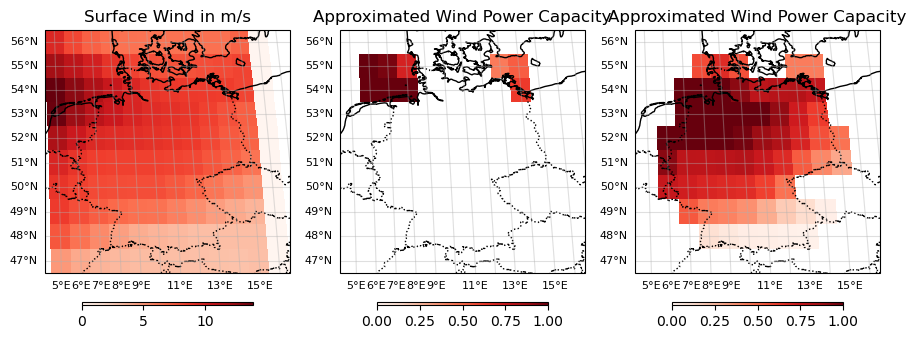

In [12]:
# Just a plot of one timestep of the wind and the approximated on- and offshore wind power capacity

lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 2

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['sfcWind'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wepot_off['wind_off_pot'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wepot_on['wind_on_pot'].isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax3)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')


plt.tight_layout()
plt.show()


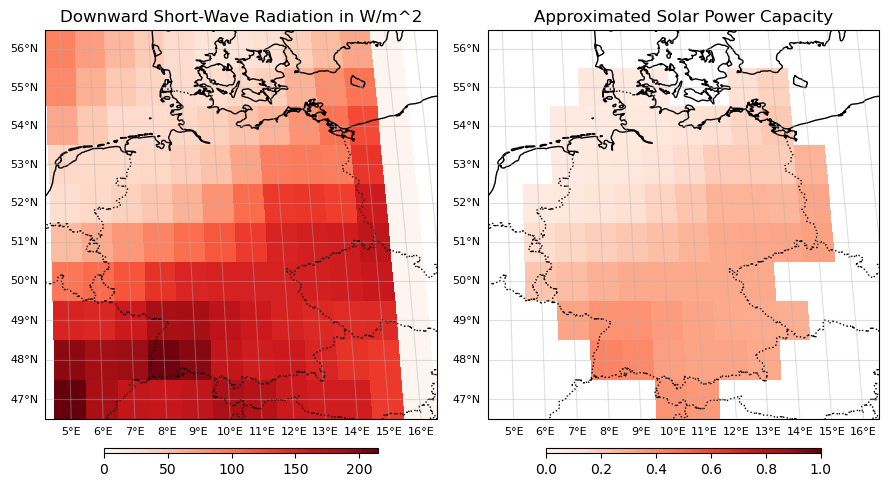

In [13]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot.where(grid_solar > 0)

# '''
lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 90# 29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['rsds'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

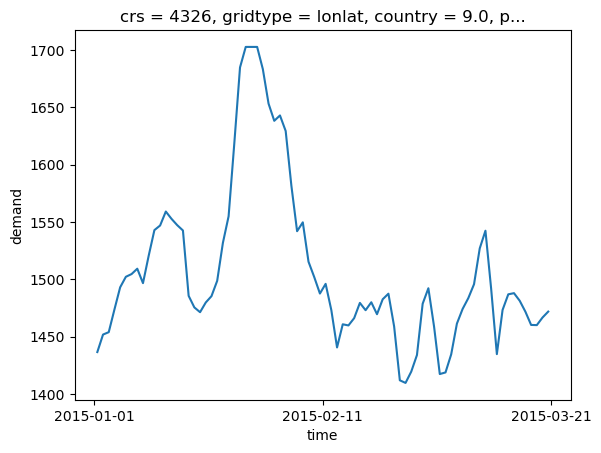

In [14]:
demand_ds['demand'][0:80].plot()

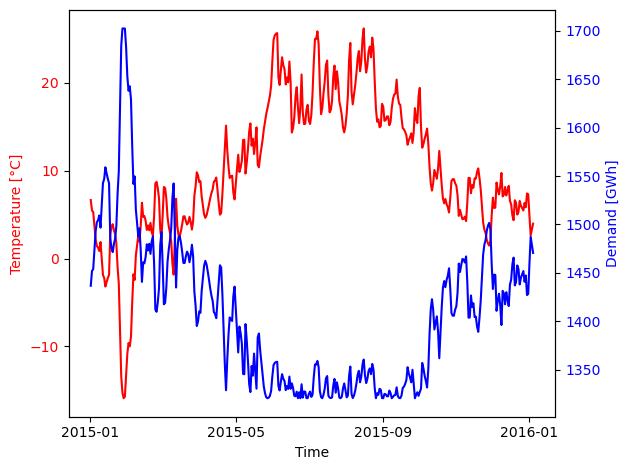

In [15]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots()

a = 0
b = 364

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.show()

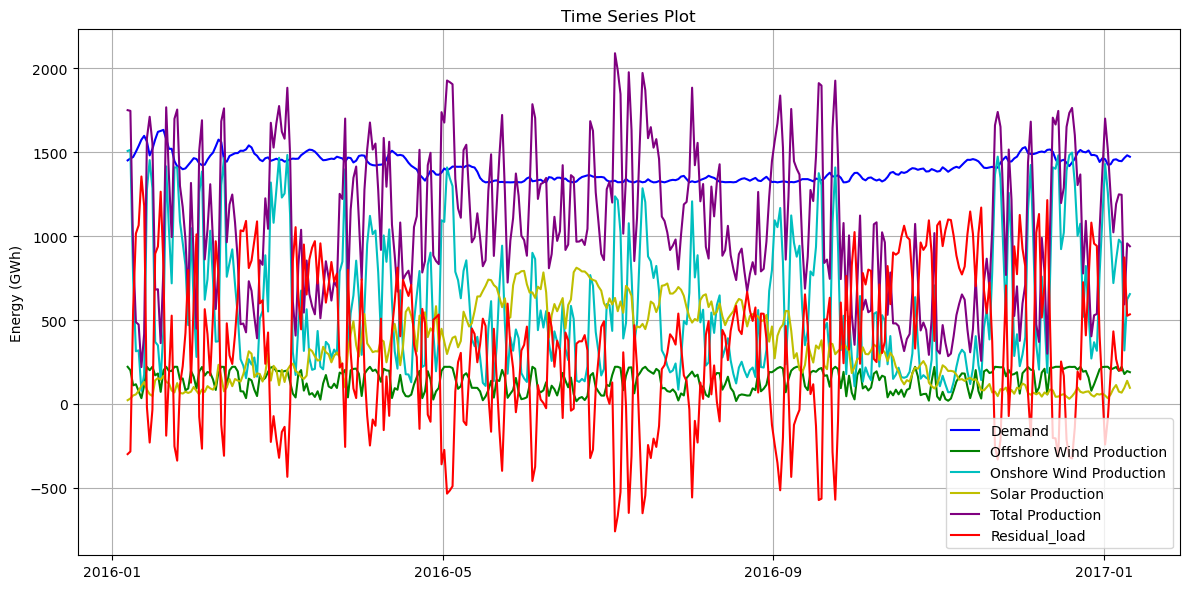

In [16]:

# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
# a = 0
# b = 364
a = 365
b = 365 * 2

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b]
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

